<a href="https://colab.research.google.com/github/lamboant01/maie383/blob/main/lab01_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MIAE 383 - Lab 1
## Measurements and features

**Time:** 140 minutes, including the opening tutorial, writing and submission.  
**Marks:** code/data 50 · analysis 20 · individual memo 20 · individual checkpoint 10.

### Start here

1. Download and extract **lab01_student_kit.zip** from Moodle.
2. Begin with **lab01_introduction.ipynb**. In [Google Colab](https://colab.research.google.com/), choose **File → Upload notebook** and save your own copy.
3. Run the notebook's setup cell. When it asks for a file, select the ZIP; leave the runtime on **CPU**.
4. After the opening, open **lab01_student.ipynb** and run its setup cell. Use **DEMO** in both code fields until staff issue your four-letter codes. This is the notebook you submit.

Before submitting, enter your own token and the section code, untick **PRACTICE**, then restart and run all cells. Update your answers for the assigned data. Preview results cannot be submitted through the export cell.

Keep the ZIP for Colab uploads. Its data and src folders contain the files the notebooks need. For local Jupyter, extract the ZIP, run `python -m pip install -r requirements-local.txt` in that folder, then open the notebook with `python -m jupyterlab`.

Work in pairs; submit your own executed notebook and **results.json** before leaving. Write the memo inside the notebook, up to 400 words. Disclose AI explanation/debugging help. Write your interpretation and memo yourself. The ungraded micro-quiz is individual, without AI or partner help.


In [1]:
from pathlib import Path
import sys, json, zipfile
_roots = [Path.cwd(), Path.cwd()/'miae383_lab01']
ROOT = next((p for p in _roots if (p/'src/miae383/lab01_data.py').is_file()
             and (p/'data/lab01/manifest.json').is_file()), None)
if ROOT is None:
    candidates = sorted(Path.cwd().glob('*lab01*kit*.zip'))
    if not candidates:
        try:
            from google.colab import files
        except ImportError:
            raise RuntimeError('Extract lab01_student_kit.zip, open this notebook from that folder, and rerun.')
        print('Choose lab01_student_kit.zip from your downloads.')
        uploaded = files.upload()
        candidates = [Path(name) for name in uploaded if name.lower().endswith('.zip')]
    if len(candidates) != 1:
        raise RuntimeError('Choose exactly one Lab 1 support ZIP. Keep only the current copy in this runtime.')
    ROOT = (Path.cwd()/'miae383_lab01').resolve()
    ROOT.mkdir(exist_ok=True)
    with zipfile.ZipFile(candidates[0]) as archive:
        if 'LAB01_KIT.json' not in archive.namelist():
            raise RuntimeError('This is not the Lab 1 student kit. Select lab01_student_kit.zip.')
        marker = json.loads(archive.read('LAB01_KIT.json'))
        if marker['version'] != 'lab01-recordings-2026-09-09':
            raise RuntimeError('This kit belongs to an older lab. Download the current one from Moodle.')
        for member in archive.infolist():
            target = (ROOT/member.filename).resolve()
            if not target.is_relative_to(ROOT):
                raise RuntimeError('The ZIP contains an invalid path. Request a fresh copy.')
        archive.extractall(ROOT)
sys.path.insert(0,str(ROOT/'src'))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from miae383.identity import ViewContext, is_preview_identity, check_submission_identity
from miae383.lab01_data import assigned_recordings, overview
from miae383.lab01_support import check, check_all, export_available_work
print('Lab 1 setup complete. CPU runtime is sufficient.')
print('Continue with the next cell.')


Choose lab01_student_kit.zip from your downloads.


Saving lab01_student_kit.zip to lab01_student_kit.zip
Lab 1 setup complete. CPU runtime is sufficient.
Continue with the next cell.


## Load your assigned recordings

Choose one case with your partner. The core tasks and marks are the same.

**Mechanical:** **Milling machine:** compare processed table vibration (vib_table) with spindle current (smcAC). Investigate cutting recordings and a peak near the documented cutter frequency. Segments are 8 s at 250 Hz.

**Aerospace:** **Aircraft:** compare pitch and roll during climb, cruise and approach. Measurements are in degrees, sampled at 8 Hz over 250 s segments.

**Industrial:** **Hydraulic equipment:** compare PS1/PS2 pressure cycles across component conditions. Investigate which records an outlier rule removes. Measurements are in bar, sampled at 100 Hz over 60 s cycles.

No codes yet? Leave **DEMO** in both fields to practise. Before submitting, enter your issued four-letter token and section code, untick **PRACTICE**, then restart and run all cells. Your assigned data and answers may change.

In [2]:
#@title Your Lab 1 details - change these fields, then run
PRACTICE = False #@param {type:"boolean"}
# No token yet? Use DEMO to explore the lab.
STUDENT_TOKEN = "KBWC" #@param {type:"string"}
SECTION_ID = "AI" #@param ["AI", "BI", "CI", "DI", "FI"]
BRANCH = "industrial" #@param ["mechanical", "aerospace", "industrial"]
# No section code yet? Use DEMO to explore the lab.
RELEASE_CODE = "JRXG" #@param {type:"string"}
PAIR_ID = "78" #@param {type:"string"}

# Before submitting: replace BOTH defaults with your issued four-letter codes; untick PRACTICE.
# Then restart and run all cells; update your answers for your assigned data.
_token = 'DEMO' if PRACTICE else STUDENT_TOKEN.strip()
_release = 'DEMO' if PRACTICE else RELEASE_CODE.strip()
try:
    context = ViewContext(_token,1,SECTION_ID,BRANCH,_release)
except (TypeError,ValueError) as error:
    raise ValueError('Enter your four-letter student token and section code, or DEMO to practise. '
                     +str(error)) from None
view = assigned_recordings(context, ROOT/'data')
SEED = view['metadata']['model_seed']
_completed_stages = {}
results = {'view_id':context.public_manifest()['view_id']}
feature_table = None
print('PREVIEW: replace both DEMO values, untick PRACTICE, then restart and run all cells before submitting.'
      if PRACTICE or is_preview_identity(context.student_token, context.release_code)
      else 'ASSIGNED VIEW - save these details in your notebook')
display(overview(view))


ASSIGNED VIEW - save these details in your notebook
UCI / ZeMA condition monitoring of hydraulic systems
Ready: 300 recordings × 2 channels × 6000 samples
Sampling: 100 Hz; 60 s per recording
Channels: PS1 (bar); PS2 (bar)
Your spectrum record: cycle-0262
View: a02f04bd4d2b
The classroom export contains added copies/missing cells; the recordings remain unchanged.


,record_id,group_id,condition
0,cycle-0213,cycle-0213,cooler 3%
1,cycle-0214,cycle-0214,cooler 3%
2,cycle-0218,cycle-0218,cooler 3%
3,cycle-0220,cycle-0220,cooler 3%
4,cycle-0235,cycle-0235,cooler 3%


### What the objects mean

| Object | Meaning |
| --- | --- |
| `view['signals']` | Actual recordings: recording × channel × sample |
| `view['record_ids']` | Original source identities; retain them when filtering |
| `view['annotations']` | Recorded conditions/group IDs for interpretation |
| `view['raw']` | A labelled classroom feature-table export with added copies/missing cells |
| `view['signal']` | Your assigned primary-channel recording for the spectrum |

A recording supplies one feature-table row. An individual sample within that recording is not a separate labelled physical experiment. Missing measured wear outcomes remain missing.

Leave time for the individual writing, quiz and submission.


## L1.DOMAIN - 5 analysis points

In at most 50 words: identify one recording, the primary measurement and units, the engineering use of its features, and one inference the source cannot establish.

Your response: Recoding index 0, measuring cooler condition in %. Engineering us is to log data for debug and history. It's the status quo.

### Your function: describe_measurement - 5 code points

Summarize finite values: return count, missing, mean, median and population std (ddof=0). Count nonfinite values as missing. Flatten the supplied values. If none are finite, return count=0, missing=the number supplied, and NaN for mean, median and std. Do not change the input.

**Example:** [1, 3, NaN, infinity] gives count=2, missing=2, mean=2, median=2 and std=1. Use `np.isfinite` to select finite values.

In [12]:
def describe_measurement(values):
    x = np.asarray(values, dtype=float).ravel()
    finite = x[np.isfinite(x)]
    return {"count":int(finite.size), "missing":int(x.size-finite.size), "mean":float(finite.mean()),
           "median":float(np.median(finite)), "std":float(finite.std(ddof=0))}

In [11]:
check('describe_measurement', globals())


describe_measurement: public examples passed. Try one boundary case from the contract.


True

### Your function: recording_features - 10 code points

Input: a finite 2D array, one row per recording, at least one recording and two samples per recording. Return a pandas DataFrame with columns mean, std, rms, range, in that order and the original recording order. Use population std, RMS=sqrt(mean(x**2)), and range=max−min along the sample axis. Reject wrong dimensions, empty/short recordings or nonfinite input with ValueError. Do not change the input.

**Example:** [1, 3] gives mean=2, std=1, RMS=√5 and range=2. Reduce axis=1 to summarize each recording. Check RMS² = mean² + std².

In [13]:
def recording_features(signals):
    x = np.asarray(signals, dtype=float)

    # Validate input dimensions
    if x.ndim != 2:
        raise ValueError("Input must be a 2D array")

    # Must contain at least 1 recording and 2 samples per recording
    if x.shape[0] < 1 or x.shape[1] < 2:
        raise ValueError("Each recording must contain at least two samples")

    # Reject NaN and infinity
    if not np.all(np.isfinite(x)):
        raise ValueError("Input must contain only finite values")

    # Calculate features along each recording (axis=1)
    mean = np.mean(x, axis=1)
    std = np.std(x, axis=1, ddof=0)   # population standard deviation
    rms = np.sqrt(np.mean(x ** 2, axis=1))
    value_range = np.max(x, axis=1) - np.min(x, axis=1)

    # Return DataFrame with required column order
    return pd.DataFrame({
        "mean": mean,
        "std": std,
        "rms": rms,
        "range": value_range
    })

In [14]:
check('recording_features', globals())


recording_features: public examples passed. Try one boundary case from the contract.


True

### Investigation 1 - Calculate recording features

Inspect the same recording as a time trace and as numerical summaries. The first channel is primary. Use the provided loop to keep both channels and the source-record order.

,record_id,PS1_mean,PS1_std,PS1_rms,PS1_range,PS2_mean,PS2_std,PS2_rms,PS2_range
0,cycle-0213,156.366353,16.208856,157.204209,56.71,104.530172,46.206975,114.287538,165.38
1,cycle-0214,156.485143,15.378330,157.238968,52.84,105.118359,46.101129,114.783203,163.79
2,cycle-0218,156.801327,15.086058,157.525380,50.06,105.544400,46.227999,115.224339,165.81
3,cycle-0220,156.560662,15.186978,157.295534,49.27,105.228850,46.155099,114.906066,163.64
4,cycle-0235,156.138147,15.238284,156.879974,50.07,105.454132,45.640854,114.907187,165.88


,record_id,group_id,condition
0,cycle-0213,cycle-0213,cooler 3%
1,cycle-0214,cycle-0214,cooler 3%
2,cycle-0218,cycle-0218,cooler 3%
3,cycle-0220,cycle-0220,cooler 3%
4,cycle-0235,cycle-0235,cooler 3%


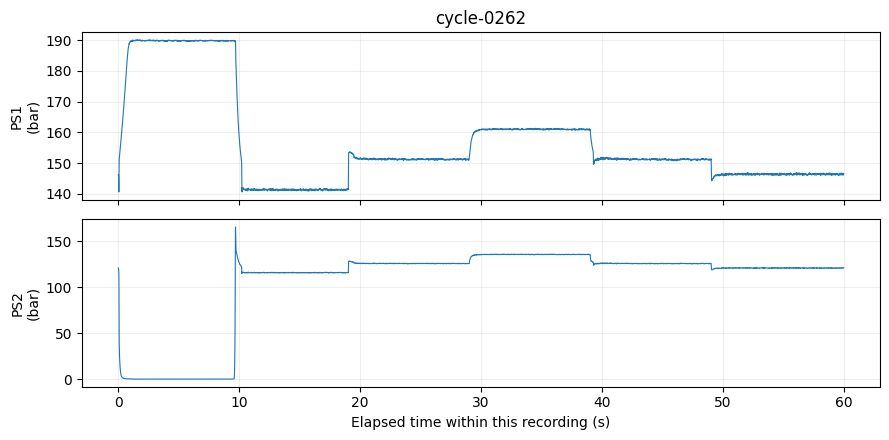

In [15]:
feature_parts = []
for j, channel in enumerate(view['channels']):
    block = recording_features(view['signals'][:, j, :])
    feature_parts.append(block.reset_index(drop=True).add_prefix(channel + '_'))
feature_table = pd.concat(feature_parts, axis=1)
feature_table.insert(0, 'record_id', view['record_ids'].to_numpy())
primary = view['metadata']['primary_measurement']
display(feature_table.head())
display(view['annotations'][['record_id', 'group_id', 'condition']].head())
idx = view['signal_index']
time_s = np.arange(view['signals'].shape[-1]) / view['sample_rate_hz']
fig, axes = plt.subplots(2, 1, figsize=(9, 4.5), sharex=True)
for j, ax in enumerate(axes):
    ax.plot(time_s, view['signals'][idx, j], lw=.8)
    ax.set_ylabel(view['channels'][j] + '\n(' + view['units'][j] + ')')
    ax.grid(alpha=.2)
axes[-1].set_xlabel('Elapsed time within this recording (s)')
axes[0].set_title(view['metadata']['selected_signal_record_id'])
plt.tight_layout(); plt.show()

_completed_stages[1] = context.public_manifest()['view_id']


### Your function: clean_records - 15 code points

Return (clean_frame, report). Remove exact duplicate rows before imputation; preserve first-occurrence order and reset the index. Reject conflicting duplicate record_id with ValueError. In the named measurement columns, replace nonfinite values by missing and fill with that column's finite median. Reject an all-missing measurement column. Do not change the input. report contains duplicates_removed and imputed, a per-column count after deduplication and before filling.

**Example:** (a,10), (b,missing), (c,14), (c,14) becomes (a,10), (b,12), (c,14). Remove copies before calculating the median. Equal readings with different record IDs are not duplicates.

In [21]:
def clean_records(frame, measurement_columns):
    # Work on a copy so the original input is not changed
    clean_frame = frame.copy()

    # Remove exact duplicate rows first
    original_count = len(clean_frame)
    clean_frame = clean_frame.drop_duplicates(keep="first").reset_index(drop=True)
    duplicates_removed = original_count - len(clean_frame)

    # After exact duplicates are removed, repeated record_id means conflict
    if clean_frame["record_id"].duplicated().any():
        raise ValueError("Conflicting duplicate record_id")

    # Track number of values imputed for each measurement column
    imputed = {}

    for column in measurement_columns:
        # Replace +inf and -inf with missing values
        clean_frame[column] = clean_frame[column].replace(
            [np.inf, -np.inf], np.nan
        )

        # Count missing values before filling
        missing_count = clean_frame[column].isna().sum()
        imputed[column] = int(missing_count)

        # Reject column if every value is missing/nonfinite
        if clean_frame[column].isna().all():
            raise ValueError(f"All values are missing in column: {column}")

        # Calculate finite median and fill missing values
        median = clean_frame[column].median()
        clean_frame[column] = clean_frame[column].fillna(median)

    report = {
        "duplicates_removed": duplicates_removed,
        "imputed": imputed
    }

    return clean_frame, report

In [18]:
check('clean_records', globals())


clean_records: public examples passed. Try one boundary case from the contract.


True

### Investigation 2 - Clean the export

The export has deliberately introduced copies and missing feature cells. The original sampled recordings remain intact. Apply the published cleaning rule and compare the result with the unchanged feature table.

In [22]:
measurement_columns = list(view['X'].columns)
clean, cleaning_report = clean_records(view['raw'], measurement_columns)
summary = describe_measurement(clean[primary])
display(pd.DataFrame({'quantity': ['Export rows', 'Original recordings', 'Cleaned rows'],
                      'count': [len(view['raw']), len(feature_table), len(clean)]}))
print('Cleaning report:', cleaning_report)
missing_ids = view['raw'].loc[~np.isfinite(view['raw'][primary]), 'record_id'].unique()
comparison = clean.set_index('record_id').loc[missing_ids, [primary]].rename(columns={primary:'imputed_export'})
comparison['original_feature'] = feature_table.set_index('record_id').loc[missing_ids, primary]
display(comparison)
print('Imputation supplies a usable input; it does not recover the original measurement.')

_completed_stages[2] = context.public_manifest()['view_id']


,quantity,count
0,Export rows,306
1,Original recordings,300
2,Cleaned rows,300


Cleaning report: {'duplicates_removed': 6, 'imputed': {'PS1_mean': 4, 'PS1_std': 0, 'PS1_rms': 0, 'PS1_range': 0, 'PS2_mean': 0, 'PS2_std': 0, 'PS2_rms': 0, 'PS2_range': 0}}


,imputed_export,original_feature
record_id,,
cycle-1143,159.034101,158.493947
cycle-2148,159.034101,160.684972
cycle-1921,159.034101,160.933267
cycle-0214,159.034101,156.485143


Imputation supplies a usable input; it does not recover the original measurement.


### Your function: flag_unusual - 5 code points

Return a Boolean array in the original shape. Compute Q1 and Q3 from finite values using linear-interpolated quantiles. Flag values strictly below Q1−1.5*(Q3−Q1) or strictly above Q3+1.5*(Q3−Q1). Nonfinite entries are False. With no finite entries, return all False. Keep all records; this function flags and never deletes.

**Example:** [0,1,2,3,100] gives Q1=1, Q3=3 and fences −2 and 6. Only 100 is flagged.

In [23]:
def flag_unusual(values):
    x = np.asarray(values, dtype=float)
    finite = np.isfinite(x)
    flags = np.zeros(x.shape, dtype=bool)

    # If there are no finite values, return all False
    if not finite.any():
        return flags

    # Use only finite values to calculate quartiles
    finite_values = x[finite]

    Q1 = np.quantile(finite_values, 0.25, method="linear")
    Q3 = np.quantile(finite_values, 0.75, method="linear")

    # Interquartile range
    IQR = Q3 - Q1

    # Calculate lower and upper fences
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Flag only finite values strictly outside the fences
    flags[finite] = (
        (x[finite] < lower) |
        (x[finite] > upper)
    )

    return flags

In [24]:
check('flag_unusual', globals())


flag_unusual: public examples passed. Try one boundary case from the contract.


True

### Investigation 3 - Inspect flagged records

Use the unchanged recording-derived mean, not the altered classroom export, for this investigation. The rule is a global comparison across the assigned operating conditions. Count what would be lost if its flags were deleted.

,recorded_condition,available,would_remove,would_retain,fraction_removed
0,cooler 100%,97,0,97,0.000000
1,cooler 20%,104,0,104,0.000000
2,cooler 3%,99,39,60,0.393939


Flagged source records: ['cycle-0347', 'cycle-0353', 'cycle-0355', 'cycle-0357', 'cycle-0360', 'cycle-0372', 'cycle-0374', 'cycle-0376']


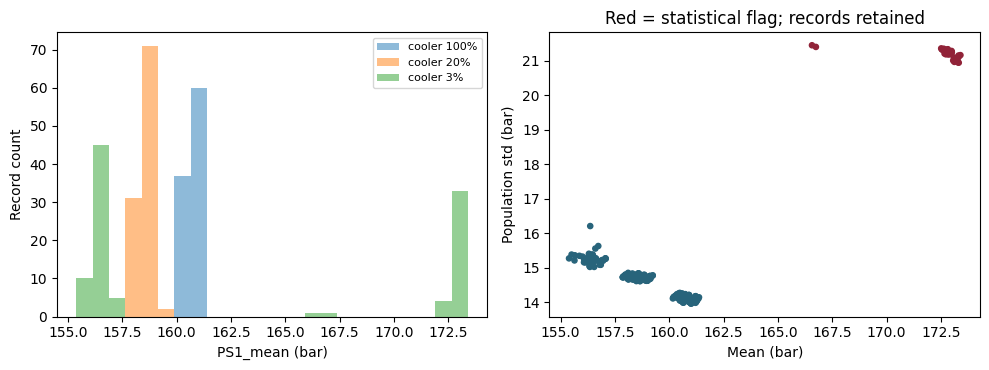

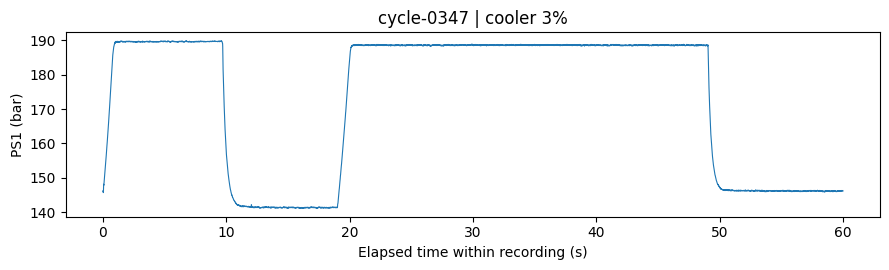

In [25]:
from miae383.lab01_data import compare_removals
unusual = flag_unusual(feature_table[primary].to_numpy())
consequence = compare_removals(view, unusual)
display(consequence)
source_summary = describe_measurement(feature_table[primary])
print('Flagged source records:', feature_table.loc[unusual, 'record_id'].head(8).tolist())
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
condition = view['annotations']['condition'].to_numpy()
bins = np.histogram_bin_edges(feature_table[primary], bins=24)
for label in sorted(np.unique(condition)):
    values = feature_table.loc[condition == label, primary]
    axes[0].hist(values, bins=bins, alpha=.5, label=label)
axes[0].set(xlabel=primary+' ('+view['units'][0]+')', ylabel='Record count')
axes[0].legend(fontsize=8)
axes[1].scatter(feature_table[primary], feature_table[view['channels'][0]+'_std'],
                c=np.where(unusual, '#912338', '#28647B'), s=14)
axes[1].set(xlabel='Mean ('+view['units'][0]+')',
            ylabel='Population std ('+view['units'][0]+')',
            title='Red = statistical flag; records retained')
plt.tight_layout(); plt.show()
selected = int(np.flatnonzero(unusual)[0]) if unusual.any() else int(np.argmax(feature_table[primary]))
plt.figure(figsize=(9,2.8))
plt.plot(time_s, view['signals'][selected,0], lw=.8)
plt.xlabel('Elapsed time within recording (s)')
plt.ylabel(view['channels'][0]+' ('+view['units'][0]+')')
plt.title(str(view['record_ids'].iloc[selected])+' | '+str(condition[selected]))
plt.tight_layout(); plt.show()

_completed_stages[3] = context.public_manifest()['view_id']


Does the rule remove a larger share of one condition? Inspect one flagged trace, or the largest unflagged trace if none are flagged. What evidence would establish a recording error?

For hydraulics, `unstable=0` means the operating conditions stabilized; it does not mean the equipment is healthy. Several component settings vary together. For flights, phase differences can be expected operating changes. For milling, material and cutting setup can change signal level. A statistical flag alone cannot settle any of these physical questions.

### Your function: amplitude_spectrum - 15 code points

Return (frequency_hz, amplitude) from a mean-removed real FFT with a rectangular window. Divide abs(rfft) by N; double positive interior bins, but not DC or the even-length Nyquist bin. Require a finite 1D signal with at least two samples and a positive finite scalar sample rate, otherwise ValueError. A constant signal has zero amplitude. Preserve the input.

Use `rfftfreq(N, d=1/fs)` for the frequency axis. With even N, the last bin is Nyquist and stays undoubled. With odd N, double the last positive bin. Preserve sample timing.

In [27]:
def amplitude_spectrum(signal, sample_rate_hz):
    x = np.asarray(signal, dtype=float)

    # Validate signal
    if x.ndim != 1:
        raise ValueError("Signal must be 1D")

    if x.size < 2:
        raise ValueError("Signal must have at least two samples")

    if not np.all(np.isfinite(x)):
        raise ValueError("Signal must contain only finite values")

    # Validate sample rate
    if not np.isscalar(sample_rate_hz):
        raise ValueError("Sample rate must be a scalar")

    fs = float(sample_rate_hz)

    if not np.isfinite(fs) or fs <= 0:
        raise ValueError("Sample rate must be positive and finite")

    N = len(x)

    # Remove the mean
    x_centered = x - np.mean(x)

    # Real FFT
    spectrum = np.fft.rfft(x_centered)

    # Frequency axis
    frequency_hz = np.fft.rfftfreq(N, d=1 / fs)

    # Amplitude scaling
    amplitude = np.abs(spectrum) / N

    # Double positive interior bins
    if N % 2 == 0:
        # Even N: do not double DC or Nyquist
        amplitude[1:-1] *= 2
    else:
        # Odd N: no Nyquist bin, so double everything except DC
        amplitude[1:] *= 2

    return frequency_hz, amplitude

In [ ]:
check('amplitude_spectrum', globals())


### Investigation 4 - Examine the spectrum

First find the largest nonzero component of your assigned primary recording. Then read the branch question. For milling, a peak near a predicted frequency and the largest overall peak are different quantities.

**Milling:** use 826 rpm and six inserts to calculate the nominal frequencies. Compare the overall maximum with the strongest Hann-window peak in 78-87 Hz. Propose a spindle-speed or acquisition-timing check to investigate an offset.

**Flight:** compare the phase's time trace and spectrum. What further evidence would identify the fluctuation as a particular flight mode?

**Hydraulics:** compare the pressure waveform with the 60-second load cycle. A peak can describe repeated pressure changes; it does not identify a fault or pump geometry.

Record: cycle-0262
N: 6000 | fs (Hz): 100.0 | bin spacing (Hz): 0.016666666666666666
Largest nonzero component: 0.03333333333333333 Hz
One-sided amplitude: 14.7784131180003 bar
Plot focuses on cycle-scale pressure changes below 2 Hz; Nyquist is 50 Hz.
The 60 s load cycle and its pressure steps can create several spectral components.


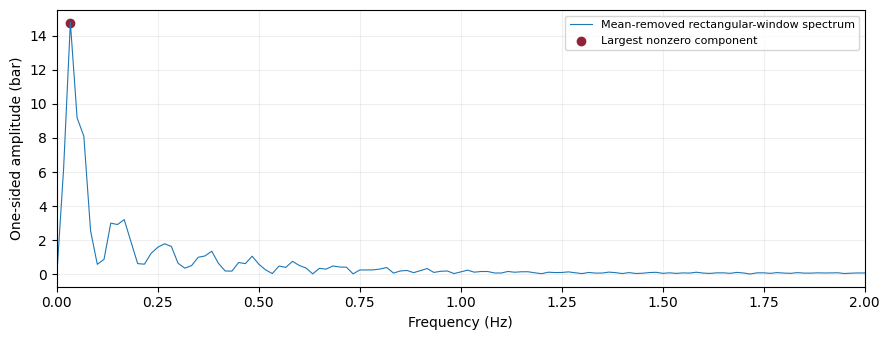

A zero in primary_peak_hz denotes no resolved positive-frequency component.


,record_id,PS1_mean,PS1_std,PS1_rms,PS1_range,PS2_mean,PS2_std,PS2_rms,PS2_range,primary_peak_hz
0,cycle-0213,156.366353,16.208856,157.204209,56.71,104.530172,46.206975,114.287538,165.38,0.033333
1,cycle-0214,156.485143,15.378330,157.238968,52.84,105.118359,46.101129,114.783203,163.79,0.033333
2,cycle-0218,156.801327,15.086058,157.525380,50.06,105.544400,46.227999,115.224339,165.81,0.033333
3,cycle-0220,156.560662,15.186978,157.295534,49.27,105.228850,46.155099,114.906066,163.64,0.033333
4,cycle-0235,156.138147,15.238284,156.879974,50.07,105.454132,45.640854,114.907187,165.88,0.033333


In [28]:
frequency, amplitude = amplitude_spectrum(view['signal'], view['sample_rate_hz'])
peak_index = 1 + int(np.argmax(amplitude[1:]))
dominant_frequency_hz = float(frequency[peak_index])
print('Record:', view['metadata']['selected_signal_record_id'])
print('N:', len(view['signal']), '| fs (Hz):', view['sample_rate_hz'],
      '| bin spacing (Hz):', view['sample_rate_hz']/len(view['signal']))
print('Largest nonzero component:', dominant_frequency_hz, 'Hz')
print('One-sided amplitude:', float(amplitude[peak_index]), view['units'][0])
fig, ax = plt.subplots(figsize=(9,3.5))
ax.plot(frequency, amplitude, lw=.8, label='Mean-removed rectangular-window spectrum')
ax.scatter([frequency[peak_index]], [amplitude[peak_index]], c='#912338', label='Largest nonzero component')
ax.set(xlabel='Frequency (Hz)', ylabel='One-sided amplitude ('+view['units'][0]+')')
if BRANCH == 'mechanical':
    expected_rotation_hz = 826/60
    expected_tooth_hz = 6*expected_rotation_hz

    # Correct Hann amplitudes for coherent gain.
    window = np.hanning(len(view['signal']))
    centred = view['signal'] - np.mean(view['signal'])
    f_hann, a_hann = amplitude_spectrum(centred*window, view['sample_rate_hz'])
    a_hann = a_hann/window.mean()
    band = (f_hann >= 78) & (f_hann <= 87)
    comparison_peak_hz = float(f_hann[band][np.argmax(a_hann[band])])
    print('Nominal rotation (Hz):', expected_rotation_hz)
    print('Nominal tooth passing (Hz):', expected_tooth_hz)
    print('Strongest Hann-window peak in the stated 78–87 Hz band:', comparison_peak_hz)
    print('Measured minus nominal (Hz):', comparison_peak_hz-expected_tooth_hz)
    ax.plot(f_hann, a_hann, lw=.8, alpha=.7, label='Supplied Hann comparison')
    ax.axvline(expected_tooth_hz, color='black', ls='--', label='Nominal 82.6 Hz reference')
    ax.set_xlim(0,100)
elif BRANCH == 'aerospace':
    ax.set_xlim(0,.5)
    print('Plot focuses on slow motion below 0.5 Hz; the native Nyquist limit is 4 Hz.')
    print('A dominant pitch component does not on its own identify an aircraft mode or fault.')
else:
    ax.set_xlim(0,2)
    print('Plot focuses on cycle-scale pressure changes below 2 Hz; Nyquist is 50 Hz.')
    print('The 60 s load cycle and its pressure steps can create several spectral components.')
ax.grid(alpha=.2); ax.legend(fontsize=8); plt.tight_layout(); plt.show()

frequency_features = []
for signal in view['signals'][:,0,:]:
    f, a = amplitude_spectrum(signal, view['sample_rate_hz'])
    k = 1 + int(np.argmax(a[1:]))
    resolved = a[k] > 64*np.finfo(float).eps*max(1.,np.max(np.abs(signal)))
    frequency_features.append(float(f[k]) if resolved else 0.)
feature_table['primary_peak_hz'] = frequency_features
print('A zero in primary_peak_hz denotes no resolved positive-frequency component.')
display(feature_table.head())
results = {'duplicate_count':int(cleaning_report['duplicates_removed']),
           'view_id':view['metadata']['view_id'],
           'clean_primary_mean':float(summary['mean']),
           'dominant_frequency_hz':dominant_frequency_hz,
           'unusual_count':int(unusual.sum()),
           'records_in_feature_table':len(feature_table),
           'condition_retention':consequence.to_dict(orient='records'),
           'spectrum_record_id':view['metadata']['selected_signal_record_id']}
if BRANCH == 'mechanical':
    results['nominal_tooth_passing_hz'] = expected_tooth_hz
    results['comparison_peak_hz'] = comparison_peak_hz

_completed_stages[4] = context.public_manifest()['view_id']


## L1.EDA - 10 analysis points

Keep the cleaning comparison, feature plot and labelled spectrum. In at most 50 words each, explain (a) how the outlier rule changes the represented conditions and whether removal is justified; (b) your measured spectral component and the evidence needed to identify its physical cause.

Your response: The rule removes 52 of 103 cooler 3% records, none from other conditions are removed. Therefore we cannot depend on the flags alone; the dominant component is at 0.033Hz (30sec period), identifying the cause requires mathcing it to load cycle and equipment timing.

### Investigation 5 - Prediction example (supplied, ungraded)

Run this brief illustration. Identify the inputs, the separately recorded outcome and one prediction that could need checking. Model fitting and validation will be assessed in Lab 2.

In [29]:
from miae383.lab01_data import prediction_demo
display(prediction_demo(view, feature_table))

_completed_stages[5] = context.public_manifest()['view_id']


Supplied nearest-centroid illustration (recorded category)
The model receives numerical features. IDs and condition labels are not input features.
The observations shown below were held out by the supplied source-group split.
These are illustrative predictions; no score is required for credit.


,record_id,measured_or_recorded,predicted
0,cycle-0213,cooler 3%,cooler 3%
1,cycle-0214,cooler 3%,cooler 3%
2,cycle-0218,cooler 3%,cooler 20%
3,cycle-0262,cooler 3%,cooler 20%
4,cycle-0297,cooler 3%,cooler 20%
5,cycle-0300,cooler 3%,cooler 20%
6,cycle-0310,cooler 3%,cooler 20%
7,cycle-0391,cooler 3%,cooler 3%


## L1.KNOWLEDGE-GAP - 3 analysis points

In at most 40 words, identify one missing fact that could change your recommendation, and one specific source or measurement that would resolve it.

Your response: One missing fact could be faulty pressure sensor, therefore compare it to other sensors that are calibrated to see if unusual pattern is a measurement error.

## L1.MEMO-REVISION - 2 analysis points

Record an initial claim and a revised claim (at most 25 words each), then identify the evidence that changed it (at most 25 words).

Your response: initial: the flagged 3% should be removed as an outlier. revised: remove only if they are measurement errors.

## Individual engineering memo - 20 points

Use your notebook results. Stay within each section limit, up to 400 words in total.

### Decision - maximum 50 words

State your recommendation about retaining measurements or using the feature table, for the conditions examined.

Your response:

### Evidence - maximum 100 words

Cite your own counts, source IDs, feature values or frequencies with units. Refer to notebook plots rather than describing every plotted point.

Your response:

### Interpretation - maximum 100 words

Explain why those observations support the recommendation. Separate measurement, association and physical explanation.

Your response:

### Limitations - maximum 100 words

State the main limitation and what it prevents you from concluding.

Your response:

### Next action - maximum 50 words

Specify one measurement or source check and the result that would support or challenge your recommendation.

Your response:

## Individual contribution and assistance

**Contribution:** at most 40 words per member: name an actual contribution and a substantive check of the partner's work.

**AI disclosure:** up to 60 words on help used and how you checked it, or “None.” Include built-in assistants.

**Individual checkpoint - 10 points:** explanation 4, contribution/review 3, next check/handover 3. Both students must answer.

Your response:

## Individual formative micro-quiz - 8 minutes, 0 marks

Use your assigned results. No partner or AI help.

1. Using your assigned raw table, how many exact ingestion-duplicate rows are present beyond their first occurrence? Enter an integer.

2. After applying the prescribed cleaning procedure, what is the arithmetic mean of the measurement identified as primary_measurement in your data dictionary? Report six decimal places.

3. For your assigned signal segment, what is the dominant nonzero FFT frequency in hertz after removing the mean? Report three decimal places.

## Finish and submit - before leaving

1. Replace both **DEMO** codes with your issued values and untick **PRACTICE**. Restart and run all cells, then update your plots and written responses for the assigned data.
2. Run the export cell and download **results.json**. Unfinished functions or failed checks do not prevent export.
3. Download the notebook: **File → Download → Download .ipynb**.
4. Upload both files before leaving and confirm the submitted copies.

The final cell shows a provisional code score from the public checks, out of 50. The automatic grader uses additional tests, so its final mark may differ. If an unfinished task stops execution, run the remaining function definitions and the final export cell to submit what you completed. Missing results are recorded as incomplete.

If disconnected, reopen the saved copy and rerun setup with the same token and code. Ask a demonstrator for help with platform failures.

In [ ]:
#@title Check and export
DOWNLOAD_RESULTS = True #@param {type:"boolean"}
export_path = export_available_work(globals(), context, PAIR_ID, view,
                                    practice=PRACTICE, download=DOWNLOAD_RESULTS)
